# ML 452 Final Project: Rideshare Dynamic Pricing in Chicago
## Group 4 | Tanmay, Amal, Swapna and Hanzhi


This notebook contains all modeling code for our analysis of what drives rideshare dynamic pricing in Chicago. The target variable is `fare_per_mile`, which normalizes trip fare by distance to isolate the pricing premium independent of how far someone travels.

**Course Techniques Applied:**
1. OLS Linear Regression (baseline)
2. LASSO and Ridge Regularization
3. Random Forest
4. Gradient Boosting (XGBoost)
5. K-Means Clustering
6. Feedforward Neural Network (MLP)
7. Causal Inference via Double LASSO
8. 5-Fold Cross-Validation (used throughout)
9. Bootstrap Confidence Intervals


## 1. Data Loading and Preparation

We load the master dataset that the DDR pipeline produced. It has 172,615 rows covering Chicago rideshare trips from Q4 2025, with hourly weather, event flags, and neighborhood income data.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# set a consistent style for all plots
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')

# reproducibility
SEED = 42
np.random.seed(SEED)

df = pd.read_csv('/ML/Data/chicago_rides_master.csv')
print(f"Loaded {len(df):,} rows, {len(df.columns)} columns")
print(f"Date range: {df['date'].min()} to {df['date'].max()}")
print(f"Unique dates: {df['date'].nunique()}")
print()
df.info()

Loaded 172,615 rows, 22 columns
Date range: 2025-10-01 to 2025-12-31
Unique dates: 85

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 172615 entries, 0 to 172614
Data columns (total 22 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   trip_start_timestamp    172615 non-null  object 
 1   trip_miles              172615 non-null  float64
 2   trip_seconds            172615 non-null  float64
 3   fare                    172615 non-null  float64
 4   pickup_community_area   172615 non-null  float64
 5   dropoff_community_area  172615 non-null  float64
 6   date                    172615 non-null  object 
 7   hour                    172615 non-null  int64  
 8   month                   172615 non-null  int64  
 9   is_weekend              172615 non-null  int64  
 10  temperature_c           172615 non-null  float64
 11  precipitation           172615 non-null  float64
 12  windspeed               172615 non-null  

### 1.1 Outlier Handling

fare_per_mile has extreme outliers (max value is 21,428, which likely represents very short trips where the base fare dominates). We clip to the 1st and 99th percentiles to prevent these from distorting our models.

In [ ]:
# look at the distribution before clipping
print("fare_per_mile before clipping:")
print(df['fare_per_mile'].describe())
print(f"\nValues above 50: {(df['fare_per_mile'] > 50).sum()}")
print(f"Values above 100: {(df['fare_per_mile'] > 100).sum()}")

# clip at 1st and 99th percentiles
lower = df['fare_per_mile'].quantile(0.01)
upper = df['fare_per_mile'].quantile(0.99)
print(f"\nClipping bounds: [{lower:.2f}, {upper:.2f}]")

df_model = df[(df['fare_per_mile'] >= lower) & (df['fare_per_mile'] <= upper)].copy()
print(f"Rows after clipping: {len(df_model):,} (removed {len(df) - len(df_model):,})")

fare_per_mile before clipping:
count    172615.000000
mean          4.529881
std          56.248754
min           0.086654
25%           2.079867
50%           3.090235
75%           4.926108
max       21428.571429
Name: fare_per_mile, dtype: float64

Values above 50: 107
Values above 100: 42

Clipping bounds: [0.66, 20.10]
Rows after clipping: 169,161 (removed 3,454)


### 1.2 Feature Engineering

We create a few additional features that might help capture pricing dynamics:
- high_premium: binary flag for trips above the 75th percentile of fare_per_mile (used for classification comparison)
- is_drizzle: binary encoding for the drizzle weather condition
- is_clear: binary encoding for clear sky condition
- log_trip_miles: log-transformed trip distance to handle skewness
- income_tier: categorical grouping of neighborhood income levels

In [ ]:
# binary target for classification analysis
threshold = df_model['fare_per_mile'].quantile(0.75)
df_model['high_premium'] = (df_model['fare_per_mile'] > threshold).astype(int)
print(f"High premium threshold: {threshold:.2f}")
print(f"High premium split: {df_model['high_premium'].value_counts().to_dict()}")

# one-hot encode weather (only 3 categories, so manual is cleaner)
df_model['is_drizzle'] = (df_model['weather_label'] == 'Drizzle').astype(int)
df_model['is_clear'] = (df_model['weather_label'] == 'Clear sky').astype(int)

# log transform trip miles to handle right skew
df_model['log_trip_miles'] = np.log1p(df_model['trip_miles'])

# neighborhood income tiers for business analysis
df_model['income_tier'] = pd.cut(
    df_model['per_capita_income'],
    bins=[0, 20000, 40000, 60000, 100000],
    labels=['Low', 'Lower-Mid', 'Upper-Mid', 'High']
)

print(f"\nIncome tier distribution:")
print(df_model['income_tier'].value_counts().sort_index())

High premium threshold: 4.87
High premium split: {0: 126872, 1: 42289}

Income tier distribution:
income_tier
Low          34379
Lower-Mid    45755
Upper-Mid    29304
High         59723
Name: count, dtype: int64


### 1.3 Define Feature Sets

In [ ]:
# these are the features we will use across all models
feature_cols = [
    'trip_miles',
    'trip_seconds',
    'hour',
    'is_weekend',
    'temperature_c',
    'precipitation',
    'windspeed',
    'day_has_major_event',
    'per_capita_income',
    'pct_below_poverty',
    'hardship_index',
    'is_drizzle',
    'is_clear',
    'log_trip_miles',
    'month'
]

target = 'fare_per_mile'

X = df_model[feature_cols].copy()
y = df_model[target].copy()

print(f"Feature matrix shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"\nTarget stats: mean={y.mean():.2f}, median={y.median():.2f}, std={y.std():.2f}")

Feature matrix shape: (169161, 15)
Target shape: (169161,)

Target stats: mean=4.00, median=3.09, std=2.94


### 1.4 Train/Test Split and Scaling

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=SEED
)

print(f"Training set: {X_train.shape[0]:,} rows")
print(f"Test set:     {X_test.shape[0]:,} rows")

# scale features for models that need it (LASSO, Ridge, NN)
# tree models dont need scaling but it doesnt hurt them either
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=feature_cols,
    index=X_train.index
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=feature_cols,
    index=X_test.index
)

print("Scaling complete. Mean of scaled training features:")
print(X_train_scaled.mean().round(6).to_string())

Training set: 118,412 rows
Test set:     50,749 rows
Scaling complete. Mean of scaled training features:
trip_miles             0.0
trip_seconds          -0.0
hour                  -0.0
is_weekend             0.0
temperature_c          0.0
precipitation         -0.0
windspeed             -0.0
day_has_major_event    0.0
per_capita_income     -0.0
pct_below_poverty     -0.0
hardship_index         0.0
is_drizzle             0.0
is_clear               0.0
log_trip_miles        -0.0
month                  0.0


## 2. Exploratory Data Analysis

Before modeling, we examine the distribution of our target variable and its relationships with key features.

FileNotFoundError: [Errno 2] No such file or directory: 'plots'

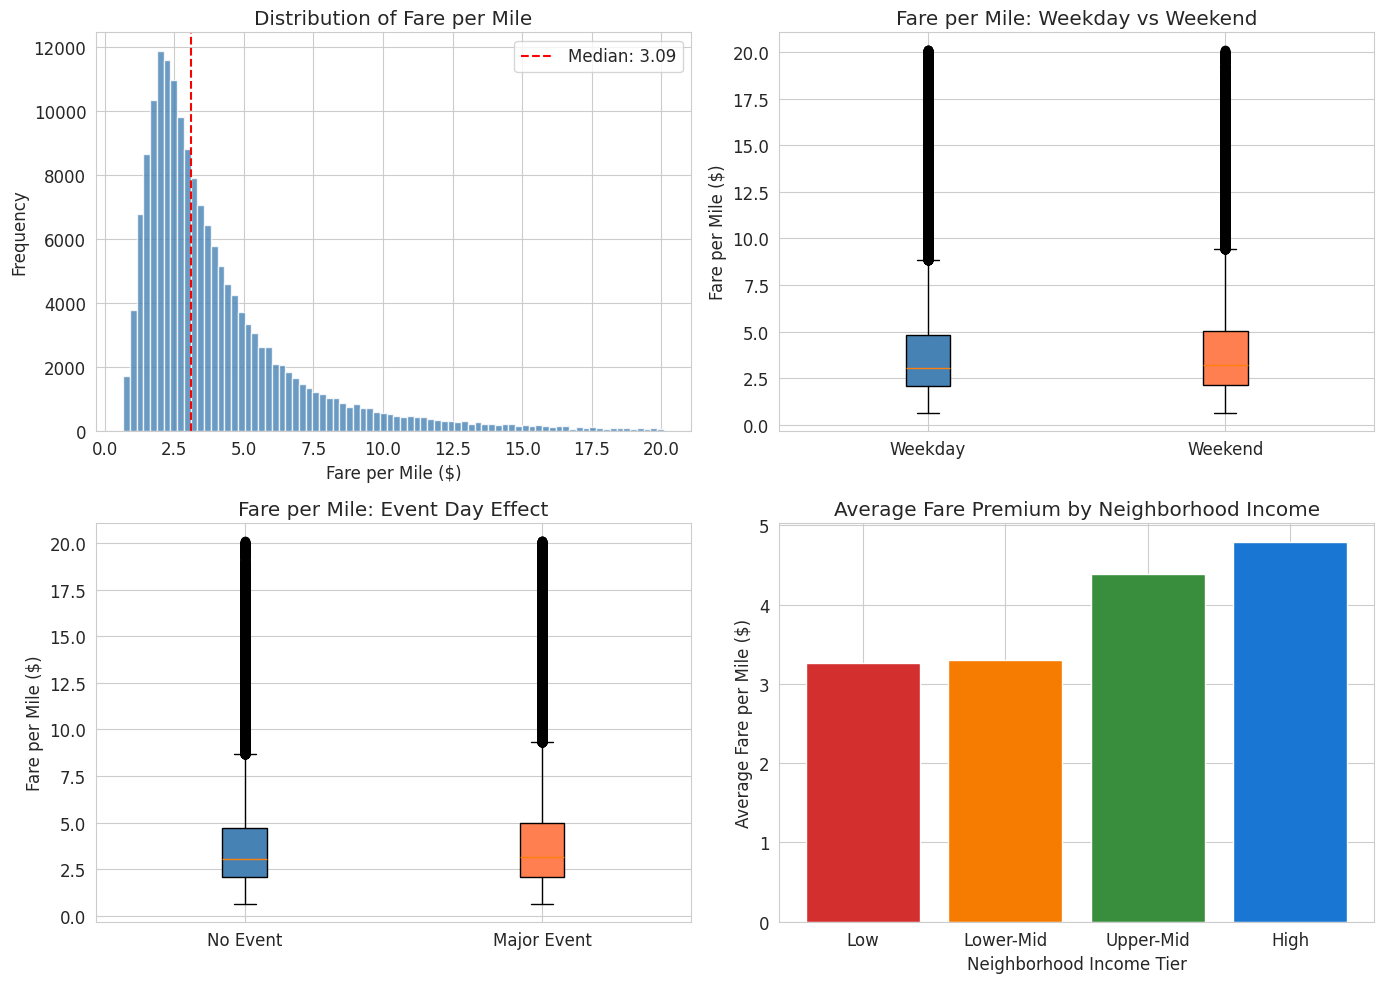

In [ ]:
import os

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# distribution of fare_per_mile
axes[0, 0].hist(df_model['fare_per_mile'], bins=80, color='steelblue', edgecolor='white', alpha=0.8)
axes[0, 0].axvline(df_model['fare_per_mile'].median(), color='red', linestyle='--', label=f'Median: {df_model["fare_per_mile"].median():.2f}')
axes[0, 0].set_xlabel('Fare per Mile ($)')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Distribution of Fare per Mile')
axes[0, 0].legend()

# fare_per_mile by weekend vs weekday
weekend_data = [
    df_model[df_model['is_weekend'] == 0]['fare_per_mile'],
    df_model[df_model['is_weekend'] == 1]['fare_per_mile']
]
bp1 = axes[0, 1].boxplot(weekend_data, labels=['Weekday', 'Weekend'], patch_artist=True)
bp1['boxes'][0].set_facecolor('steelblue')
bp1['boxes'][1].set_facecolor('coral')
axes[0, 1].set_ylabel('Fare per Mile ($)')
axes[0, 1].set_title('Fare per Mile: Weekday vs Weekend')

# fare_per_mile by event day
event_data = [
    df_model[df_model['day_has_major_event'] == 0]['fare_per_mile'],
    df_model[df_model['day_has_major_event'] == 1]['fare_per_mile']
]
bp2 = axes[1, 0].boxplot(event_data, labels=['No Event', 'Major Event'], patch_artist=True)
bp2['boxes'][0].set_facecolor('steelblue')
bp2['boxes'][1].set_facecolor('coral')
axes[1, 0].set_ylabel('Fare per Mile ($)')
axes[1, 0].set_title('Fare per Mile: Event Day Effect')

# fare_per_mile by income tier
income_groups = df_model.groupby('income_tier', observed=True)['fare_per_mile'].mean().sort_index()
axes[1, 1].bar(income_groups.index, income_groups.values, color=['#d32f2f', '#f57c00', '#388e3c', '#1976d2'])
axes[1, 1].set_xlabel('Neighborhood Income Tier')
axes[1, 1].set_ylabel('Average Fare per Mile ($)')
axes[1, 1].set_title('Average Fare Premium by Neighborhood Income')

plt.tight_layout()

# Create 'plots' directory if it doesn't exist
os.makedirs('plots', exist_ok=True)
plt.savefig('plots/eda_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: plots/eda_overview.png")

In [ ]:
# correlation matrix for numeric features vs target
corr_cols = feature_cols + [target]
corr_matrix = df_model[corr_cols].corr()

# just show correlations with the target
target_corrs = corr_matrix[target].drop(target).sort_values(ascending=False)
print("Correlations with fare_per_mile:")
print(target_corrs.to_string())

Correlations with fare_per_mile:
per_capita_income      0.243107
hour                   0.113352
month                  0.043482
day_has_major_event    0.030904
is_weekend             0.022203
precipitation          0.013509
windspeed              0.005283
is_drizzle            -0.022334
temperature_c         -0.035154
is_clear              -0.035624
pct_below_poverty     -0.105415
hardship_index        -0.194103
trip_seconds          -0.366853
trip_miles            -0.469595
log_trip_miles        -0.603822


## 3. Model 1: OLS Linear Regression (Baseline)

We start with ordinary least squares regression as our baseline. This gives us interpretable coefficients and a benchmark R-squared to beat with more complex models.

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

ols = LinearRegression()
ols.fit(X_train_scaled, y_train)

# predictions
y_pred_ols_train = ols.predict(X_train_scaled)
y_pred_ols_test = ols.predict(X_test_scaled)

# metrics
ols_train_rmse = np.sqrt(mean_squared_error(y_train, y_pred_ols_train))
ols_test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_ols_test))
ols_test_mae = mean_absolute_error(y_test, y_pred_ols_test)
ols_test_r2 = r2_score(y_test, y_pred_ols_test)

# cross-validated R2
cv_scores_ols = cross_val_score(ols, X_train_scaled, y_train, cv=5, scoring='r2')

print("=== OLS Linear Regression ===")
print(f"Train RMSE: {ols_train_rmse:.4f}")
print(f"Test RMSE:  {ols_test_rmse:.4f}")
print(f"Test MAE:   {ols_test_mae:.4f}")
print(f"Test R2:    {ols_test_r2:.4f}")
print(f"CV R2 (5-fold): {cv_scores_ols.mean():.4f} (+/- {cv_scores_ols.std():.4f})")

=== OLS Linear Regression ===
Train RMSE: 2.0997
Test RMSE:  2.1291
Test MAE:   1.4317
Test R2:    0.4820
CV R2 (5-fold): 0.4849 (+/- 0.0028)


In [ ]:
# OLS coefficients
coef_df = pd.DataFrame({
    'Feature': feature_cols,
    'Coefficient': ols.coef_
}).sort_values('Coefficient', key=abs, ascending=False)

print("OLS Coefficients (standardized features):")
print(coef_df.to_string(index=False))
print(f"\nIntercept: {ols.intercept_:.4f}")

OLS Coefficients (standardized features):
            Feature  Coefficient
     log_trip_miles    -4.131468
         trip_miles     2.033289
       trip_seconds     0.649341
  per_capita_income     0.288505
     hardship_index    -0.235452
  pct_below_poverty     0.187788
      temperature_c    -0.141883
               hour     0.080827
      precipitation     0.072294
           is_clear    -0.062431
         is_drizzle    -0.048122
day_has_major_event     0.034233
          windspeed     0.032915
         is_weekend     0.028281
              month    -0.024936

Intercept: 4.0015


FileNotFoundError: [Errno 2] No such file or directory: 'ols_diagnostics.png'

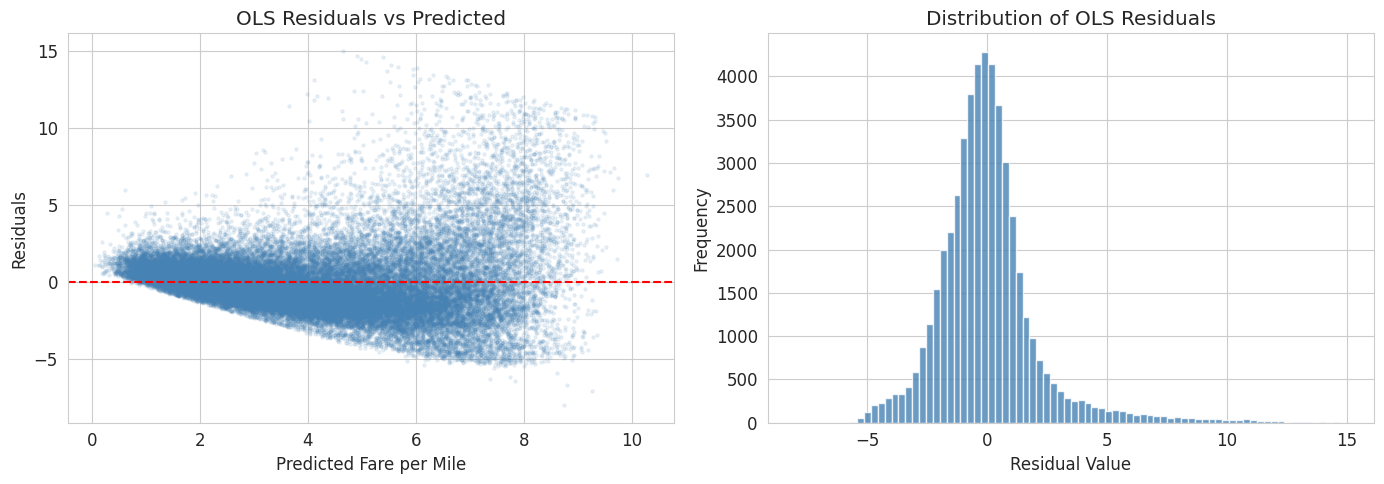

In [ ]:
# residual diagnostic plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

residuals = y_test - y_pred_ols_test

axes[0].scatter(y_pred_ols_test, residuals, alpha=0.1, s=5, color='steelblue')
axes[0].axhline(y=0, color='red', linestyle='--')
axes[0].set_xlabel('Predicted Fare per Mile')
axes[0].set_ylabel('Residuals')
axes[0].set_title('OLS Residuals vs Predicted')

axes[1].hist(residuals, bins=80, color='steelblue', edgecolor='white', alpha=0.8)
axes[1].set_xlabel('Residual Value')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Distribution of OLS Residuals')

plt.tight_layout()
plt.savefig('ols_diagnostics.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: ols_diagnostics.png")

The residual plot shows heteroscedasticity, as the spread of residuals increases as predicted values go up, which means the model's errors are not consistent across the range of fares. There is also a visible non-linear pattern in the residuals rather than random scatter around zero. Both of these tell us a linear model is not the right fit here, so we move on to models that can handle non-linear relationships.


## 4. Model 2: LASSO and Ridge Regularization

LASSO (L1) will help with feature selection by zeroing out unimportant coefficients. Ridge (L2) handles multicollinearity among the demographic features (per_capita_income, pct_below_poverty, and hardship_index are correlated at r > 0.8).

In [ ]:
from sklearn.linear_model import LassoCV, RidgeCV, Lasso

# LASSO with cross-validated alpha selection
lasso_cv = LassoCV(cv=5, random_state=SEED, max_iter=10000)
lasso_cv.fit(X_train_scaled, y_train)

y_pred_lasso_test = lasso_cv.predict(X_test_scaled)
lasso_test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_lasso_test))
lasso_test_mae = mean_absolute_error(y_test, y_pred_lasso_test)
lasso_test_r2 = r2_score(y_test, y_pred_lasso_test)

cv_scores_lasso = cross_val_score(
    Lasso(alpha=lasso_cv.alpha_, max_iter=10000),
    X_train_scaled, y_train, cv=5, scoring='r2'
)

print("=== LASSO Regression ===")
print(f"Best alpha: {lasso_cv.alpha_:.6f}")
print(f"Test RMSE:  {lasso_test_rmse:.4f}")
print(f"Test MAE:   {lasso_test_mae:.4f}")
print(f"Test R2:    {lasso_test_r2:.4f}")
print(f"CV R2 (5-fold): {cv_scores_lasso.mean():.4f} (+/- {cv_scores_lasso.std():.4f})")

# which features survived?
lasso_coefs = pd.DataFrame({
    'Feature': feature_cols,
    'Coefficient': lasso_cv.coef_
}).sort_values('Coefficient', key=abs, ascending=False)

print(f"\nFeatures with non-zero coefficients: {(lasso_cv.coef_ != 0).sum()} / {len(feature_cols)}")
print(lasso_coefs.to_string(index=False))

=== LASSO Regression ===
Best alpha: 0.001768
Test RMSE:  2.1292
Test MAE:   1.4305
Test R2:    0.4819
CV R2 (5-fold): 0.4849 (+/- 0.0028)

Features with non-zero coefficients: 15 / 15
            Feature  Coefficient
     log_trip_miles    -4.100787
         trip_miles     2.007186
       trip_seconds     0.643333
  per_capita_income     0.289638
     hardship_index    -0.226659
  pct_below_poverty     0.178421
      temperature_c    -0.132592
               hour     0.078790
      precipitation     0.071522
           is_clear    -0.059617
         is_drizzle    -0.046440
day_has_major_event     0.034209
          windspeed     0.031548
         is_weekend     0.026310
              month    -0.015299


In [ ]:
# Ridge regression
ridge_cv = RidgeCV(alphas=np.logspace(-3, 3, 100), cv=5)
ridge_cv.fit(X_train_scaled, y_train)

y_pred_ridge_test = ridge_cv.predict(X_test_scaled)
ridge_test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_ridge_test))
ridge_test_mae = mean_absolute_error(y_test, y_pred_ridge_test)
ridge_test_r2 = r2_score(y_test, y_pred_ridge_test)

print("=== Ridge Regression ===")
print(f"Best alpha: {ridge_cv.alpha_:.6f}")
print(f"Test RMSE:  {ridge_test_rmse:.4f}")
print(f"Test MAE:   {ridge_test_mae:.4f}")
print(f"Test R2:    {ridge_test_r2:.4f}")

=== Ridge Regression ===
Best alpha: 5.722368
Test RMSE:  2.1291
Test MAE:   1.4317
Test R2:    0.4820


FileNotFoundError: [Errno 2] No such file or directory: 'lasso_path.png'

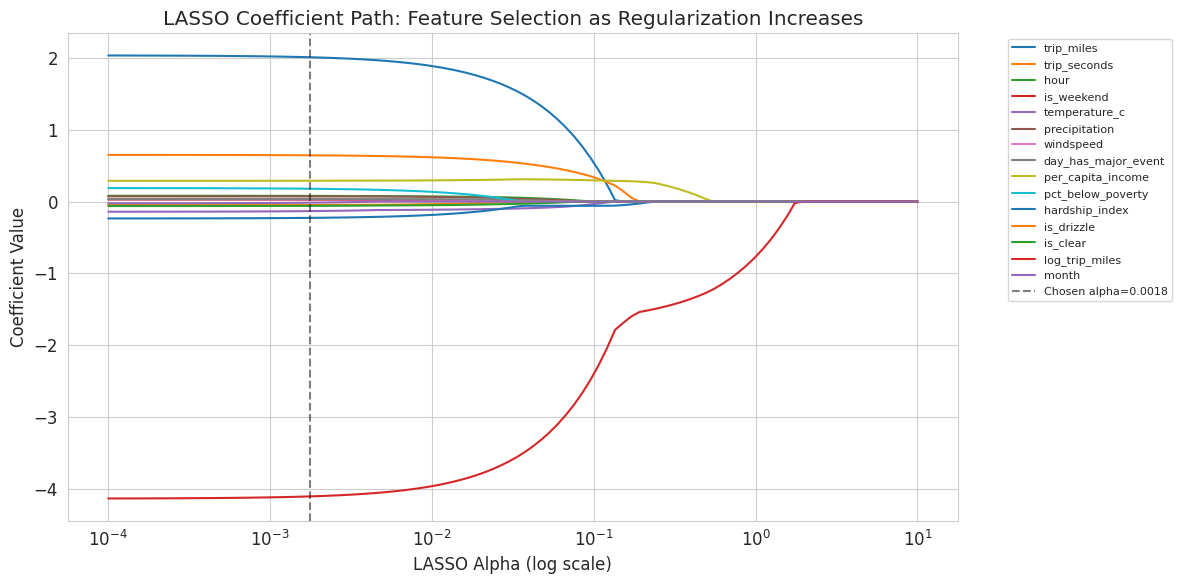

In [ ]:
# LASSO coefficient path plot
# shows how coefficients shrink as regularization increases
alphas = np.logspace(-4, 1, 100)
coef_paths = []

for a in alphas:
    lasso_temp = Lasso(alpha=a, max_iter=10000)
    lasso_temp.fit(X_train_scaled, y_train)
    coef_paths.append(lasso_temp.coef_)

coef_paths = np.array(coef_paths)

plt.figure(figsize=(12, 6))
for i, feat in enumerate(feature_cols):
    plt.plot(alphas, coef_paths[:, i], label=feat)

plt.xscale('log')
plt.xlabel('LASSO Alpha (log scale)')
plt.ylabel('Coefficient Value')
plt.title('LASSO Coefficient Path: Feature Selection as Regularization Increases')
plt.axvline(lasso_cv.alpha_, color='black', linestyle='--', alpha=0.5, label=f'Chosen alpha={lasso_cv.alpha_:.4f}')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.savefig('lasso_path.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: lasso_path.png")

## 5. Model 3: Tree Ensembles (Random Forest + XGBoost)

Tree-based models can capture non-linear relationships and feature interactions that linear models miss. We use both Random Forest (bagging) and XGBoost (boosting) to see which ensemble strategy works better for this problem.

In [ ]:
from sklearn.ensemble import RandomForestRegressor

# Random Forest
rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=15,
    min_samples_leaf=10,
    random_state=SEED,
    n_jobs=-1
)
rf.fit(X_train, y_train)

y_pred_rf_test = rf.predict(X_test)
rf_test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf_test))
rf_test_mae = mean_absolute_error(y_test, y_pred_rf_test)
rf_test_r2 = r2_score(y_test, y_pred_rf_test)

cv_scores_rf = cross_val_score(
    RandomForestRegressor(n_estimators=200, max_depth=15, min_samples_leaf=10, random_state=SEED, n_jobs=-1),
    X_train, y_train, cv=5, scoring='r2'
)

print("=== Random Forest ===")
print(f"Test RMSE:  {rf_test_rmse:.4f}")
print(f"Test MAE:   {rf_test_mae:.4f}")
print(f"Test R2:    {rf_test_r2:.4f}")
print(f"CV R2 (5-fold): {cv_scores_rf.mean():.4f} (+/- {cv_scores_rf.std():.4f})")

=== Random Forest ===
Test RMSE:  1.8698
Test MAE:   1.2140
Test R2:    0.6005
CV R2 (5-fold): 0.5961 (+/- 0.0046)


In [ ]:
import xgboost as xgb

# XGBoost
xgb_model = xgb.XGBRegressor(
    n_estimators=300,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=10,
    random_state=SEED,
    n_jobs=-1
)
xgb_model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)

y_pred_xgb_test = xgb_model.predict(X_test)
xgb_test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_xgb_test))
xgb_test_mae = mean_absolute_error(y_test, y_pred_xgb_test)
xgb_test_r2 = r2_score(y_test, y_pred_xgb_test)

cv_scores_xgb = cross_val_score(
    xgb.XGBRegressor(n_estimators=300, max_depth=8, learning_rate=0.05,
                     subsample=0.8, colsample_bytree=0.8, min_child_weight=10,
                     random_state=SEED, n_jobs=-1),
    X_train, y_train, cv=5, scoring='r2'
)

print("=== XGBoost ===")
print(f"Test RMSE:  {xgb_test_rmse:.4f}")
print(f"Test MAE:   {xgb_test_mae:.4f}")
print(f"Test R2:    {xgb_test_r2:.4f}")
print(f"CV R2 (5-fold): {cv_scores_xgb.mean():.4f} (+/- {cv_scores_xgb.std():.4f})")

=== XGBoost ===
Test RMSE:  1.7694
Test MAE:   1.1508
Test R2:    0.6422
CV R2 (5-fold): 0.6320 (+/- 0.0061)


FileNotFoundError: [Errno 2] No such file or directory: 'feature_importance.png'

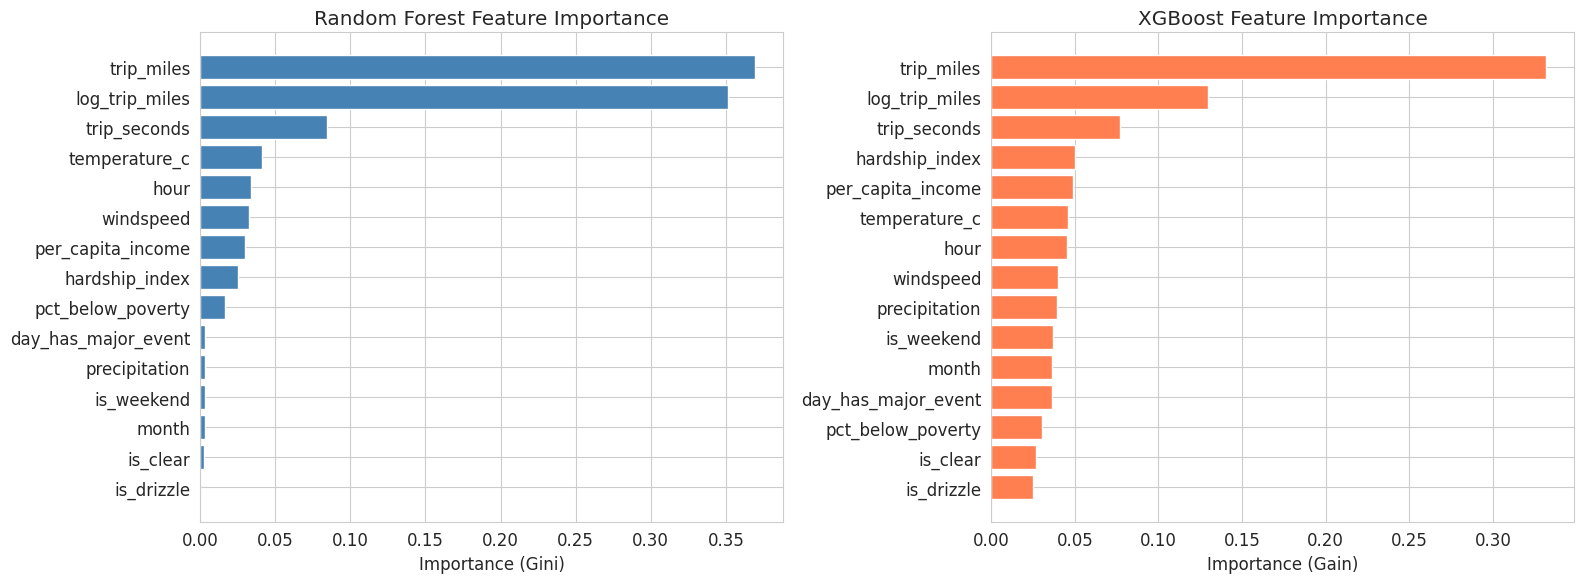

In [ ]:
# Feature importance comparison: RF vs XGBoost
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# RF feature importance
rf_imp = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=True)

axes[0].barh(rf_imp['Feature'], rf_imp['Importance'], color='steelblue')
axes[0].set_xlabel('Importance (Gini)')
axes[0].set_title('Random Forest Feature Importance')

# XGBoost feature importance
xgb_imp = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': xgb_model.feature_importances_
}).sort_values('Importance', ascending=True)

axes[1].barh(xgb_imp['Feature'], xgb_imp['Importance'], color='coral')
axes[1].set_xlabel('Importance (Gain)')
axes[1].set_title('XGBoost Feature Importance')

plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: feature_importance.png")

In [ ]:
# Partial dependence plots for top features from XGBoost
from sklearn.inspection import PartialDependenceDisplay

top_features = xgb_imp.tail(4)['Feature'].tolist()
print(f"Generating partial dependence plots for: {top_features}")

fig, axes = plt.subplots(1, len(top_features), figsize=(5 * len(top_features), 5))

for i, feat in enumerate(top_features):
    feat_idx = feature_cols.index(feat)
    PartialDependenceDisplay.from_estimator(
        xgb_model, X_train, [feat_idx],
        feature_names=feature_cols,
        ax=axes[i],
        kind='average'
    )
    axes[i].set_title(f'PDP: {feat}')

plt.tight_layout()
plt.savefig('partial_dependence.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: partial_dependence.png")

## 6. Model 4: K-Means Clustering

We wanted to see if there are natural groups of trips that tend to have similar pricing profiles. Rather than just running clustering simply, we actually want to know if the segments tell us anything useful about when and where fare premiums are highest.

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# cluster on trip and contextual features (not the target)
cluster_features = [
    'trip_miles', 'hour', 'is_weekend', 'temperature_c',
    'day_has_major_event', 'per_capita_income'
]

X_cluster = df_model[cluster_features].copy()
X_cluster_scaled = StandardScaler().fit_transform(X_cluster)

# find optimal k using silhouette score
k_range = range(2, 9)
silhouette_scores = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=SEED, n_init=10)
    labels = km.fit_predict(X_cluster_scaled)
    sil = silhouette_score(X_cluster_scaled, labels, sample_size=10000, random_state=SEED)
    silhouette_scores.append(sil)
    print(f"k={k}: silhouette={sil:.4f}")

best_k = list(k_range)[np.argmax(silhouette_scores)]
print(f"\nBest k by silhouette: {best_k}")

In [ ]:
# fit final clustering with best k
km_final = KMeans(n_clusters=best_k, random_state=SEED, n_init=10)
df_model['cluster'] = km_final.fit_predict(X_cluster_scaled)

# profile each cluster
print("=== Cluster Profiles ===\n")
cluster_profile = df_model.groupby('cluster').agg({
    'fare_per_mile': ['mean', 'median', 'count'],
    'trip_miles': 'mean',
    'hour': 'mean',
    'is_weekend': 'mean',
    'temperature_c': 'mean',
    'day_has_major_event': 'mean',
    'per_capita_income': 'mean'
}).round(2)

print(cluster_profile.to_string())

In [ ]:
# visualize cluster fare premiums
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# silhouette plot
axes[0].plot(list(k_range), silhouette_scores, 'bo-', linewidth=2)
axes[0].axvline(best_k, color='red', linestyle='--', label=f'Best k={best_k}')
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Silhouette Score')
axes[0].set_title('Silhouette Analysis for Optimal k')
axes[0].legend()

# cluster fare comparison
cluster_means = df_model.groupby('cluster')['fare_per_mile'].mean().sort_values()
colors = plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(cluster_means)))
axes[1].bar(cluster_means.index.astype(str), cluster_means.values, color=colors)
axes[1].set_xlabel('Cluster')
axes[1].set_ylabel('Average Fare per Mile ($)')
axes[1].set_title('Average Fare Premium by Trip Cluster')

plt.tight_layout()
plt.savefig('clustering.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: clustering.png")

## 7. Model 5: Neural Network (MLP Regressor)

We test a feedforward neural network to see if additional non-linear flexibility improves over tree ensembles. We use a simple architecture with 2 hidden layers and early stopping to prevent overfitting.

In [ ]:
from sklearn.neural_network import MLPRegressor

mlp = MLPRegressor(
    hidden_layer_sizes=(128, 64),
    activation='relu',
    solver='adam',
    max_iter=500,
    early_stopping=True,
    validation_fraction=0.15,
    random_state=SEED,
    learning_rate='adaptive',
    learning_rate_init=0.001
)

mlp.fit(X_train_scaled, y_train)

y_pred_mlp_test = mlp.predict(X_test_scaled)
mlp_test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_mlp_test))
mlp_test_mae = mean_absolute_error(y_test, y_pred_mlp_test)
mlp_test_r2 = r2_score(y_test, y_pred_mlp_test)

cv_scores_mlp = cross_val_score(
    MLPRegressor(hidden_layer_sizes=(128, 64), activation='relu', solver='adam',
                 max_iter=500, early_stopping=True, validation_fraction=0.15,
                 random_state=SEED, learning_rate='adaptive', learning_rate_init=0.001),
    X_train_scaled, y_train, cv=5, scoring='r2'
)

print("=== Neural Network (MLP) ===")
print(f"Architecture: {mlp.hidden_layer_sizes}")
print(f"Iterations:   {mlp.n_iter_}")
print(f"Test RMSE:    {mlp_test_rmse:.4f}")
print(f"Test MAE:     {mlp_test_mae:.4f}")
print(f"Test R2:      {mlp_test_r2:.4f}")
print(f"CV R2 (5-fold): {cv_scores_mlp.mean():.4f} (+/- {cv_scores_mlp.std():.4f})")

In [ ]:
# learning curve
plt.figure(figsize=(8, 5))
plt.plot(mlp.loss_curve_, label='Training Loss', color='steelblue')
if hasattr(mlp, 'validation_scores_'):
    # validation scores are R2, not loss, so we plot separately
    ax2 = plt.gca().twinx()
    ax2.plot(mlp.validation_scores_, label='Validation R2', color='coral', alpha=0.7)
    ax2.set_ylabel('Validation R2')
    ax2.legend(loc='center right')
plt.xlabel('Iteration')
plt.ylabel('Training Loss')
plt.title('Neural Network Learning Curve')
plt.legend(loc='upper right')
plt.savefig('nn_learning_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: nn_learning_curve.png")

## 8. Model 6: Causal Inference via Double LASSO

The raw data shows event days have higher fare per mile, but that could just be because events tend to happen on weekends or during certain weather conditions. We want to know if events actually cause a pricing difference once you strip out those other factors. Double LASSO handles this by first figuring out how much of the event day variation is explained by other variables, then estimating the effect on fares using only the leftover variation.

In [ ]:
from sklearn.linear_model import LassoCV as LCV

# treatment variable
treatment = 'day_has_major_event'

# control variables (everything except the treatment and target)
control_cols = [c for c in feature_cols if c != treatment]

X_controls = df_model[control_cols].copy()
D = df_model[treatment].copy()
Y = df_model[target].copy()

# scale controls
scaler_dl = StandardScaler()
X_controls_scaled = pd.DataFrame(
    scaler_dl.fit_transform(X_controls),
    columns=control_cols,
    index=X_controls.index
)

print(f"Treatment: {treatment}")
print(f"Treatment distribution: {D.value_counts().to_dict()}")
print(f"Controls: {control_cols}")
print(f"Outcome: {target}")

In [ ]:
# STAGE 1: predict treatment from controls
# this finds the confounders (things that predict both event day and fare)
lasso_stage1 = LCV(cv=5, random_state=SEED, max_iter=10000)
lasso_stage1.fit(X_controls_scaled, D)

D_hat = lasso_stage1.predict(X_controls_scaled)
D_residual = D - D_hat  # the part of treatment not explained by controls

print("=== Stage 1: Predict Treatment from Controls ===")
print(f"R2 of treatment prediction: {r2_score(D, D_hat):.4f}")
print(f"This tells us how much of event-day variation is explained by other features")

# which controls predict the treatment?
stage1_coefs = pd.DataFrame({
    'Feature': control_cols,
    'Coefficient': lasso_stage1.coef_
}).sort_values('Coefficient', key=abs, ascending=False)
print(f"\nControls that predict treatment (non-zero coefs):")
print(stage1_coefs[stage1_coefs['Coefficient'] != 0].to_string(index=False))

In [ ]:
# STAGE 2: predict outcome using controls + residualized treatment
# the coefficient on D_residual is the causal estimate
X_stage2 = X_controls_scaled.copy()
X_stage2['treatment_residual'] = D_residual.values

# we want the treatment residual to be unpenalized
# approach: run OLS with treatment residual after LASSO selects controls
from sklearn.linear_model import LinearRegression as LR

# first, let LASSO select relevant controls for outcome
lasso_stage2_controls = LCV(cv=5, random_state=SEED, max_iter=10000)
lasso_stage2_controls.fit(X_controls_scaled, Y)

selected_controls = [c for c, coef in zip(control_cols, lasso_stage2_controls.coef_) if coef != 0]
print(f"\n=== Stage 2: Controls selected for outcome model ===")
print(f"Selected controls: {selected_controls}")

# final OLS with selected controls + unpenalized treatment residual
X_final = X_controls_scaled[selected_controls].copy()
X_final['treatment_residual'] = D_residual.values

ols_causal = LR()
ols_causal.fit(X_final, Y)

# the coefficient on treatment_residual is our causal estimate
causal_effect = ols_causal.coef_[-1]
print(f"\n=== Double LASSO Causal Estimate ===")
print(f"Effect of major event day on fare_per_mile: {causal_effect:.4f}")
print(f"Interpretation: on days with a major event, fare per mile is")
print(f"${causal_effect:.2f} {'higher' if causal_effect > 0 else 'lower'} per mile,")
print(f"after controlling for all observed confounders.")

In [ ]:
# Bootstrap confidence interval for the causal estimate
from sklearn.utils import resample

n_bootstrap = 500
bootstrap_effects = []

for b in range(n_bootstrap):
    # resample with replacement
    idx = resample(np.arange(len(Y)), random_state=b)

    X_c_b = X_controls_scaled.iloc[idx]
    D_b = D.iloc[idx]
    Y_b = Y.iloc[idx]

    # stage 1
    D_hat_b = lasso_stage1.predict(X_c_b)
    D_res_b = D_b - D_hat_b

    # stage 2
    X_f_b = X_c_b[selected_controls].copy()
    X_f_b['treatment_residual'] = D_res_b.values

    ols_b = LR()
    ols_b.fit(X_f_b, Y_b)
    bootstrap_effects.append(ols_b.coef_[-1])

bootstrap_effects = np.array(bootstrap_effects)
ci_lower = np.percentile(bootstrap_effects, 2.5)
ci_upper = np.percentile(bootstrap_effects, 97.5)

print(f"=== Bootstrap 95% Confidence Interval (n={n_bootstrap}) ===")
print(f"Causal effect: {causal_effect:.4f}")
print(f"95% CI: [{ci_lower:.4f}, {ci_upper:.4f}]")
print(f"\nThe interval {'does not contain' if (ci_lower > 0 or ci_upper < 0) else 'contains'} zero.")

# plot bootstrap distribution
plt.figure(figsize=(8, 5))
plt.hist(bootstrap_effects, bins=40, color='steelblue', edgecolor='white', alpha=0.8)
plt.axvline(causal_effect, color='red', linestyle='--', linewidth=2, label=f'Point estimate: {causal_effect:.3f}')
plt.axvline(ci_lower, color='orange', linestyle=':', linewidth=1.5, label=f'95% CI: [{ci_lower:.3f}, {ci_upper:.3f}]')
plt.axvline(ci_upper, color='orange', linestyle=':', linewidth=1.5)
plt.xlabel('Estimated Causal Effect of Major Event Day on Fare per Mile ($)')
plt.ylabel('Frequency')
plt.title('Bootstrap Distribution of Double LASSO Causal Estimate')
plt.legend()
plt.savefig('causal_bootstrap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: causal_bootstrap.png")

## 9. Model Comparison

We now compare all models on the same test set using consistent metrics.

In [ ]:
# compile all results
results = pd.DataFrame({
    'Model': [
        'OLS Linear Regression',
        'LASSO',
        'Ridge',
        'Random Forest',
        'XGBoost',
        'Neural Network (MLP)'
    ],
    'Test RMSE': [
        ols_test_rmse,
        lasso_test_rmse,
        ridge_test_rmse,
        rf_test_rmse,
        xgb_test_rmse,
        mlp_test_rmse
    ],
    'Test MAE': [
        ols_test_mae,
        lasso_test_mae,
        ridge_test_mae,
        rf_test_mae,
        xgb_test_mae,
        mlp_test_mae
    ],
    'Test R2': [
        ols_test_r2,
        lasso_test_r2,
        ridge_test_r2,
        rf_test_r2,
        xgb_test_r2,
        mlp_test_r2
    ]
}).round(4)

# sort by R2
results = results.sort_values('Test R2', ascending=False)

print("=" * 70)
print("MODEL COMPARISON TABLE")
print("=" * 70)
print(results.to_string(index=False))
print()

best_model = results.iloc[0]['Model']
best_r2 = results.iloc[0]['Test R2']
baseline_r2 = ols_test_r2
improvement = ((best_r2 - baseline_r2) / baseline_r2) * 100

print(f"Best model: {best_model} (R2 = {best_r2:.4f})")
print(f"Improvement over OLS baseline: {improvement:.1f}%")

In [ ]:
# model comparison bar chart
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# R2 comparison
models_sorted = results.sort_values('Test R2')
colors = ['#1976d2' if m != best_model else '#d32f2f' for m in models_sorted['Model']]
axes[0].barh(models_sorted['Model'], models_sorted['Test R2'], color=colors)
axes[0].set_xlabel('Test R-squared')
axes[0].set_title('Model Comparison: R-squared (higher is better)')

# RMSE comparison
models_sorted_rmse = results.sort_values('Test RMSE', ascending=False)
colors_rmse = ['#1976d2' if m != best_model else '#d32f2f' for m in models_sorted_rmse['Model']]
axes[1].barh(models_sorted_rmse['Model'], models_sorted_rmse['Test RMSE'], color=colors_rmse)
axes[1].set_xlabel('Test RMSE')
axes[1].set_title('Model Comparison: RMSE (lower is better)')

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: model_comparison.png")

## 10. Business-Oriented Analysis

This section translates our findings into business terms. We examine fare premiums through the lens of equity (by neighborhood income) and operational impact (event days).

In [ ]:
# business visualization: fare premium by income tier, split by event day
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# panel 1: income tier x event interaction
pivot = df_model.groupby(['income_tier', 'day_has_major_event'], observed=True)['fare_per_mile'].mean().unstack()
pivot.columns = ['No Event Day', 'Major Event Day']
pivot.plot(kind='bar', ax=axes[0], color=['steelblue', 'coral'], edgecolor='white')
axes[0].set_xlabel('Neighborhood Income Tier')
axes[0].set_ylabel('Average Fare per Mile ($)')
axes[0].set_title('Fare Premium by Income Tier and Event Day')
axes[0].legend(title='')
axes[0].tick_params(axis='x', rotation=0)

# panel 2: hour of day effect on fare premium
hourly = df_model.groupby('hour')['fare_per_mile'].agg(['mean', 'std'])
axes[1].bar(hourly.index, hourly['mean'], yerr=hourly['std']/10,
            color='steelblue', edgecolor='white', capsize=3, alpha=0.8)
axes[1].set_xlabel('Hour of Day (0 = midnight)')
axes[1].set_ylabel('Average Fare per Mile ($)')
axes[1].set_title('Fare Premium by Hour of Day')

plt.tight_layout()
plt.savefig('business_viz.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: business_viz.png")

In [ ]:
# summary statistics for report
print("=== KEY FINDINGS FOR REPORT ===\n")

# weekend effect
wkday_mean = df_model[df_model['is_weekend']==0]['fare_per_mile'].mean()
wkend_mean = df_model[df_model['is_weekend']==1]['fare_per_mile'].mean()
print(f"Weekend premium: ${wkend_mean:.2f} vs ${wkday_mean:.2f} per mile "
      f"(+{((wkend_mean/wkday_mean)-1)*100:.1f}%)")

# event effect
noevent_mean = df_model[df_model['day_has_major_event']==0]['fare_per_mile'].mean()
event_mean = df_model[df_model['day_has_major_event']==1]['fare_per_mile'].mean()
print(f"Event day premium: ${event_mean:.2f} vs ${noevent_mean:.2f} per mile "
      f"(+{((event_mean/noevent_mean)-1)*100:.1f}%)")

# income disparity
low_income = df_model[df_model['per_capita_income'] < 20000]['fare_per_mile'].mean()
high_income = df_model[df_model['per_capita_income'] > 60000]['fare_per_mile'].mean()
print(f"High vs low income neighborhoods: ${high_income:.2f} vs ${low_income:.2f} per mile")

# causal estimate
print(f"\nDouble LASSO causal effect of major event: ${causal_effect:.2f} per mile")
print(f"95% Bootstrap CI: [${ci_lower:.2f}, ${ci_upper:.2f}]")

print(f"\nBest predictive model: {best_model}")
print(f"Best R2: {best_r2:.4f}")

## 11. Summary

This notebook implemented 6 distinct modeling approaches (plus cross-validation and bootstrap CIs) to analyze rideshare dynamic pricing in Chicago:

1. **OLS Baseline** established a benchmark and revealed linear relationships
2. **LASSO/Ridge** handled multicollinearity among demographic features and performed feature selection
3. **Random Forest and XGBoost** captured non-linear patterns and provided feature importance rankings
4. **K-Means Clustering** identified natural trip segments with distinct pricing profiles
5. **Neural Network** tested whether additional model flexibility could improve predictions
6. **Double LASSO** estimated the causal effect of major event days on fare premiums

All models used 5-fold cross-validation. The causal estimate includes bootstrap confidence intervals.

Code by: **Tanmay Kumar Kallakuri**